# Comparação: Distribuição da Variável "Is Laundering" ANTES e DEPOIS do Balanceamento RUS

Este notebook cria uma visualização comparativa da distribuição da variável alvo "Is Laundering" antes e depois da aplicação da técnica de balanceamento RUS (Random Under Sampling).

In [8]:
# ========================================================================
# SETUP DE PATHS
# ========================================================================
import sys
from pathlib import Path

notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    sys.path.insert(0, str(notebook_dir.parent))
else:
    sys.path.insert(0, str(notebook_dir))

from source.config import PROJ_ROOT, get_data_path, get_figure_path

# ========================================================================
# BIBLIOTECAS
# ========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler

# Configurações
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
np.random.seed(42)

print("✅ Bibliotecas importadas com sucesso!")
print(f"📁 Projeto: {PROJ_ROOT}")

✅ Bibliotecas importadas com sucesso!
📁 Projeto: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering


## 1. Carregamento dos Dados de Treino

In [9]:
# Carregar dados de treino
print("="*80)
print("CARREGAMENTO DOS DADOS")
print("="*80)

# Caminho para os dados de treino
treino_path = r'C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\data\processed\df_treino.csv'

# Carregar o dataset de treino
df_treino = pd.read_csv(treino_path)

# Separar features (X) e target (y)
# Remover colunas que não são features
colunas_para_remover = ['Is Laundering', 'Timestamp', 'From Bank', 'To Bank', 'Account', 'Account.1']
X_train = df_treino.drop(columns=colunas_para_remover, errors='ignore')
y_train = df_treino['Is Laundering']

print(f"\n📊 Dataset de Treino:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   Total de registros: {len(y_train):,}")

# Distribuição ANTES do balanceamento
print("\n" + "="*80)
print("DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING (ANTES DO BALANCEAMENTO)")
print("="*80)

value_counts_before = y_train.value_counts()
percentages_before = y_train.value_counts(normalize=True) * 100

print(f"\nClasse 0 (Normal):    {value_counts_before[0]:>12,} ({percentages_before[0]:>6.2f}%)")
print(f"Classe 1 (Lavagem):   {value_counts_before[1]:>12,} ({percentages_before[1]:>6.2f}%)")
print(f"Razão de Desbalanceamento: {value_counts_before[0]/value_counts_before[1]:.2f}:1")

CARREGAMENTO DOS DADOS

📊 Dataset de Treino:
   X_train: (14375186, 13)
   y_train: (14375186,)
   Total de registros: 14,375,186

DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING (ANTES DO BALANCEAMENTO)

Classe 0 (Normal):      14,359,659 ( 99.89%)
Classe 1 (Lavagem):         15,527 (  0.11%)
Razão de Desbalanceamento: 924.82:1


## 2. Aplicação da Técnica RUS (Random Under Sampling)

In [10]:
# Aplicar RUS
print("\n" + "="*80)
print("APLICANDO RUS (RANDOM UNDER SAMPLING)")
print("="*80)

rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

print(f"\n✅ RUS aplicado com sucesso!")
print(f"\n📊 Dataset Balanceado:")
print(f"   X_train_balanced: {X_train_balanced.shape}")
print(f"   y_train_balanced: {y_train_balanced.shape}")
print(f"   Total de registros: {len(y_train_balanced):,}")

# Distribuição DEPOIS do balanceamento
print("\n" + "="*80)
print("DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING (DEPOIS DO BALANCEAMENTO RUS)")
print("="*80)

value_counts_after = pd.Series(y_train_balanced).value_counts()
percentages_after = pd.Series(y_train_balanced).value_counts(normalize=True) * 100

print(f"\nClasse 0 (Normal):    {value_counts_after[0]:>12,} ({percentages_after[0]:>6.2f}%)")
print(f"Classe 1 (Lavagem):   {value_counts_after[1]:>12,} ({percentages_after[1]:>6.2f}%)")
print(f"Razão de Balanceamento: {value_counts_after[0]/value_counts_after[1]:.2f}:1")

# Estatísticas de redução
reduction_class0 = value_counts_before[0] - value_counts_after[0]
reduction_pct_class0 = (reduction_class0 / value_counts_before[0]) * 100

print(f"\n📉 Redução na Classe 0 (Normal):")
print(f"   {reduction_class0:,} registros removidos ({reduction_pct_class0:.2f}%)")
print(f"\n✅ A Classe 1 (Lavagem) permaneceu intacta: {value_counts_after[1]:,} registros")


APLICANDO RUS (RANDOM UNDER SAMPLING)



✅ RUS aplicado com sucesso!

📊 Dataset Balanceado:
   X_train_balanced: (31054, 13)
   y_train_balanced: (31054,)
   Total de registros: 31,054

DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING (DEPOIS DO BALANCEAMENTO RUS)

Classe 0 (Normal):          15,527 ( 50.00%)
Classe 1 (Lavagem):         15,527 ( 50.00%)
Razão de Balanceamento: 1.00:1

📉 Redução na Classe 0 (Normal):
   14,344,132 registros removidos (99.89%)

✅ A Classe 1 (Lavagem) permaneceu intacta: 15,527 registros


## 3. Visualização Comparativa


CRIANDO VISUALIZAÇÃO COMPARATIVA


C:\Users\win\AppData\Local\Temp\ipykernel_18012\4182792555.py:66: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\win\AppData\Local\Temp\ipykernel_18012\4182792555.py:70: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=300, bbox_inches='tight')



✅ Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\comparacao_balanceamento_RUS.png


C:\Users\win\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


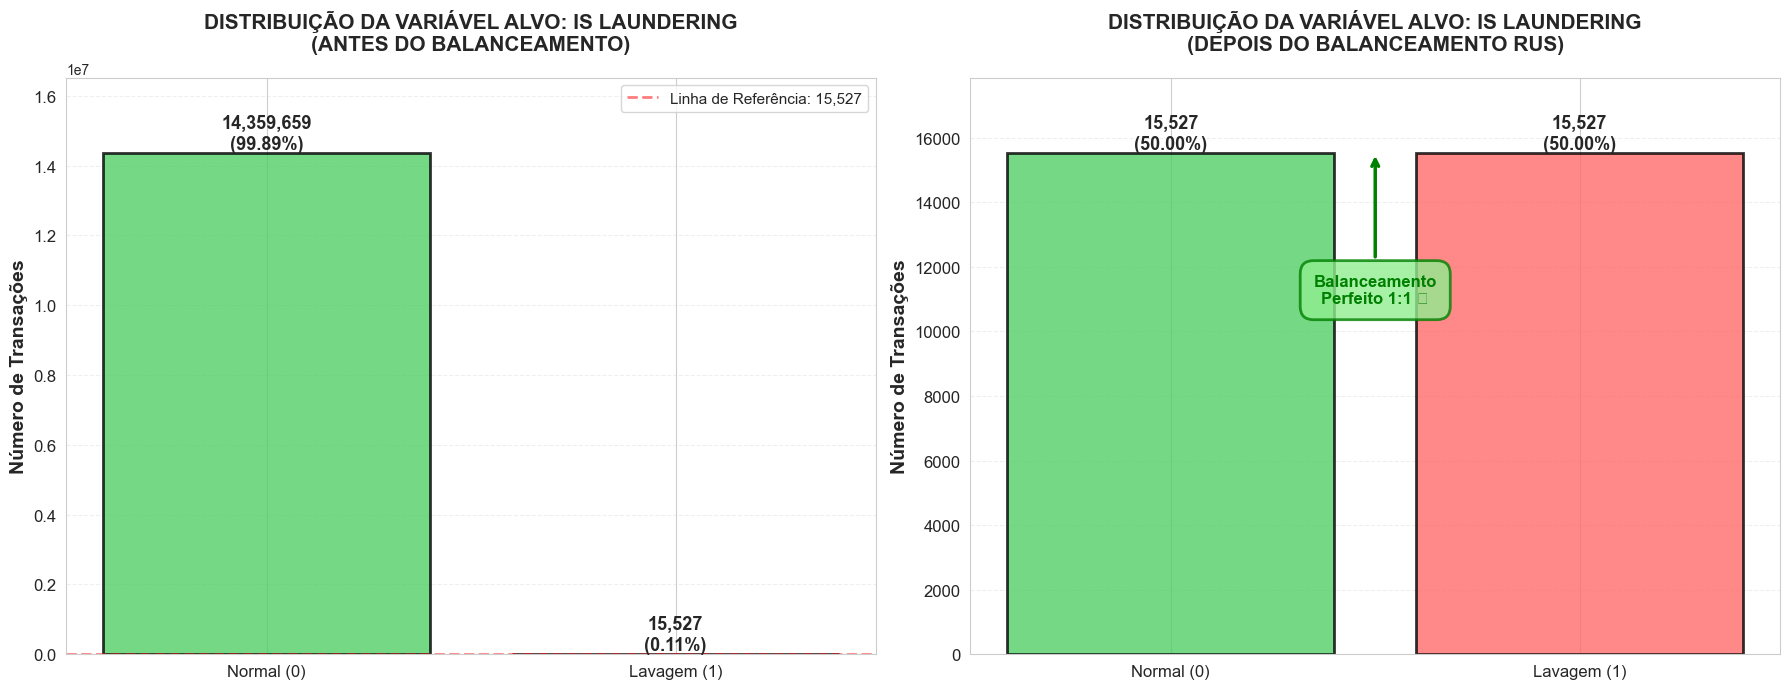

In [11]:
# Criar visualização comparativa
print("\n" + "="*80)
print("CRIANDO VISUALIZAÇÃO COMPARATIVA")
print("="*80)

# Preparar dados para visualização
classes = ['Normal (0)', 'Lavagem (1)']
before_values = [value_counts_before[0], value_counts_before[1]]
after_values = [value_counts_after[0], value_counts_after[1]]

# Criar figura com 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Cores
colors = ['#51cf66', '#ff6b6b']  # Verde para Normal, Vermelho para Lavagem

# ========================================
# GRÁFICO 1: ANTES DO BALANCEAMENTO
# ========================================
bars1 = axes[0].bar(classes, before_values, color=colors, 
                    edgecolor='black', linewidth=2, alpha=0.8)

# Adicionar valores e percentuais nas barras
for i, (val, pct) in enumerate(zip(before_values, percentages_before)):
    axes[0].text(i, val, f'{val:,}\n({pct:.2f}%)', 
                ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[0].set_ylabel('Número de Transações', fontsize=14, fontweight='bold')
axes[0].set_title('DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING\n(ANTES DO BALANCEAMENTO)', 
                 fontsize=15, fontweight='bold', pad=20)
axes[0].set_ylim(0, max(before_values) * 1.15)
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0].tick_params(axis='both', labelsize=12)

# Adicionar linha de referência
axes[0].axhline(y=value_counts_before[1], color='red', linestyle='--', 
               linewidth=2, alpha=0.5, label=f'Linha de Referência: {value_counts_before[1]:,}')
axes[0].legend(fontsize=11)

# ========================================
# GRÁFICO 2: DEPOIS DO BALANCEAMENTO
# ========================================
bars2 = axes[1].bar(classes, after_values, color=colors, 
                    edgecolor='black', linewidth=2, alpha=0.8)

# Adicionar valores e percentuais nas barras
for i, (val, pct) in enumerate(zip(after_values, percentages_after)):
    axes[1].text(i, val, f'{val:,}\n({pct:.2f}%)', 
                ha='center', va='bottom', fontsize=13, fontweight='bold')

axes[1].set_ylabel('Número de Transações', fontsize=14, fontweight='bold')
axes[1].set_title('DISTRIBUIÇÃO DA VARIÁVEL ALVO: IS LAUNDERING\n(DEPOIS DO BALANCEAMENTO RUS)', 
                 fontsize=15, fontweight='bold', pad=20)
axes[1].set_ylim(0, max(after_values) * 1.15)  # Escala ajustada para visualizar o balanceamento
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1].tick_params(axis='both', labelsize=12)

# Adicionar anotação de balanceamento perfeito
axes[1].annotate('Balanceamento\nPerfeito 1:1 ✓', 
                xy=(0.5, value_counts_after[0]), 
                xytext=(0.5, value_counts_after[0] * 0.7),
                ha='center', fontsize=12, fontweight='bold', color='green',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='lightgreen', alpha=0.8, edgecolor='green', linewidth=2),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))

plt.tight_layout()

# Salvar figura
output_path = get_figure_path('comparacao_balanceamento_RUS.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Gráfico salvo em: {output_path}")

plt.show()

## 4. Resumo da Comparação

In [12]:
# Criar tabela de resumo
print("\n" + "="*80)
print("RESUMO DA COMPARAÇÃO")
print("="*80)

summary_data = {
    'Métrica': [
        'Total de Registros',
        'Classe 0 (Normal)',
        'Classe 1 (Lavagem)',
        'Percentual Classe 0',
        'Percentual Classe 1',
        'Razão de Desbalanceamento'
    ],
    'Antes do RUS': [
        f"{len(y_train):,}",
        f"{value_counts_before[0]:,}",
        f"{value_counts_before[1]:,}",
        f"{percentages_before[0]:.2f}%",
        f"{percentages_before[1]:.2f}%",
        f"{value_counts_before[0]/value_counts_before[1]:.2f}:1"
    ],
    'Depois do RUS': [
        f"{len(y_train_balanced):,}",
        f"{value_counts_after[0]:,}",
        f"{value_counts_after[1]:,}",
        f"{percentages_after[0]:.2f}%",
        f"{percentages_after[1]:.2f}%",
        f"{value_counts_after[0]/value_counts_after[1]:.2f}:1"
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n")
display(df_summary)

print("\n" + "="*80)
print("✅ ANÁLISE CONCLUÍDA!")
print("="*80)
print(f"\n📊 Insights:")
print(f"   • RUS reduziu a classe majoritária (Normal) em {reduction_pct_class0:.2f}%")
print(f"   • A classe minoritária (Lavagem) foi preservada completamente")
print(f"   • O dataset agora está perfeitamente balanceado (1:1)")
print(f"   • Total de registros reduzidos: {len(y_train) - len(y_train_balanced):,}")
print(f"   • Percentual de dados mantidos: {(len(y_train_balanced)/len(y_train)*100):.2f}%")


RESUMO DA COMPARAÇÃO




,Métrica,Antes do RUS,Depois do RUS
0,Total de Registros,"14,375,186","31,054"
1,Classe 0 (Normal),"14,359,659","15,527"
2,Classe 1 (Lavagem),"15,527","15,527"
3,Percentual Classe 0,99.89%,50.00%
4,Percentual Classe 1,0.11%,50.00%
5,Razão de Desbalanceamento,924.82:1,1.00:1



✅ ANÁLISE CONCLUÍDA!

📊 Insights:
   • RUS reduziu a classe majoritária (Normal) em 99.89%
   • A classe minoritária (Lavagem) foi preservada completamente
   • O dataset agora está perfeitamente balanceado (1:1)
   • Total de registros reduzidos: 14,344,132
   • Percentual de dados mantidos: 0.22%


## 6. Visualização Adicional: Gráfico de Pizza Comparativo


CRIANDO GRÁFICO DE BARRAS COMPARATIVO

✅ Gráfico de barras comparativo salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\comparacao_balanceamento_RUS_barras.png


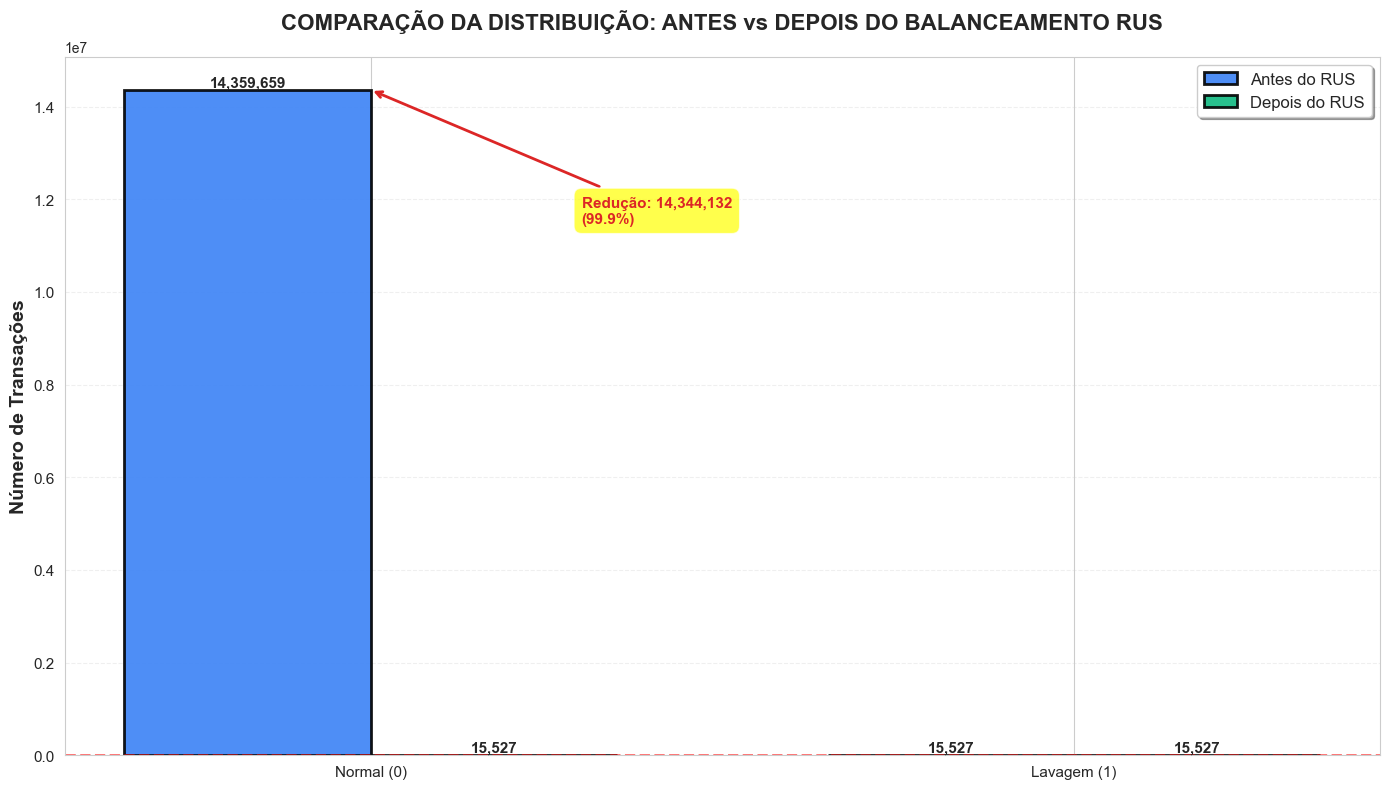

In [13]:
# Criar gráfico de barras lado a lado comparando antes e depois
print("\n" + "="*80)
print("CRIANDO GRÁFICO DE BARRAS COMPARATIVO")
print("="*80)

# Preparar dados
classes = ['Normal (0)', 'Lavagem (1)']
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))

# Criar barras lado a lado
bars_before = ax.bar(x - width/2, before_values, width, label='Antes do RUS',
                     color='#3b82f6', edgecolor='black', linewidth=2, alpha=0.9)
bars_after = ax.bar(x + width/2, after_values, width, label='Depois do RUS',
                    color='#10b981', edgecolor='black', linewidth=2, alpha=0.9)

# Adicionar valores nas barras
for bars in [bars_before, bars_after]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Configurações do gráfico
ax.set_ylabel('Número de Transações', fontsize=14, fontweight='bold')
ax.set_title('COMPARAÇÃO DA DISTRIBUIÇÃO: ANTES vs DEPOIS DO BALANCEAMENTO RUS',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=13)
ax.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.tick_params(axis='both', labelsize=11)

# Adicionar linha de balanceamento
balance_line = value_counts_after[0]
ax.axhline(y=balance_line, color='red', linestyle='--', linewidth=2, 
           alpha=0.6, label=f'Nível Balanceado: {balance_line:,}')

# Adicionar anotação de redução
reduction = value_counts_before[0] - value_counts_after[0]
ax.annotate(f'Redução: {reduction:,}\n({reduction_pct_class0:.1f}%)',
            xy=(0, value_counts_before[0]), 
            xytext=(0.3, value_counts_before[0] * 0.8),
            fontsize=11, fontweight='bold', color='#dc2626',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='#dc2626', lw=2))

plt.tight_layout()

# Salvar figura
output_path_bars = get_figure_path('comparacao_balanceamento_RUS_barras.png')
plt.savefig(output_path_bars, dpi=300, bbox_inches='tight')
print(f"\n✅ Gráfico de barras comparativo salvo em: {output_path_bars}")

plt.show()

## 5. Gráfico de Barras Comparativo (Lado a Lado)


✅ Gráfico de pizza salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\comparacao_balanceamento_RUS_pizza.png


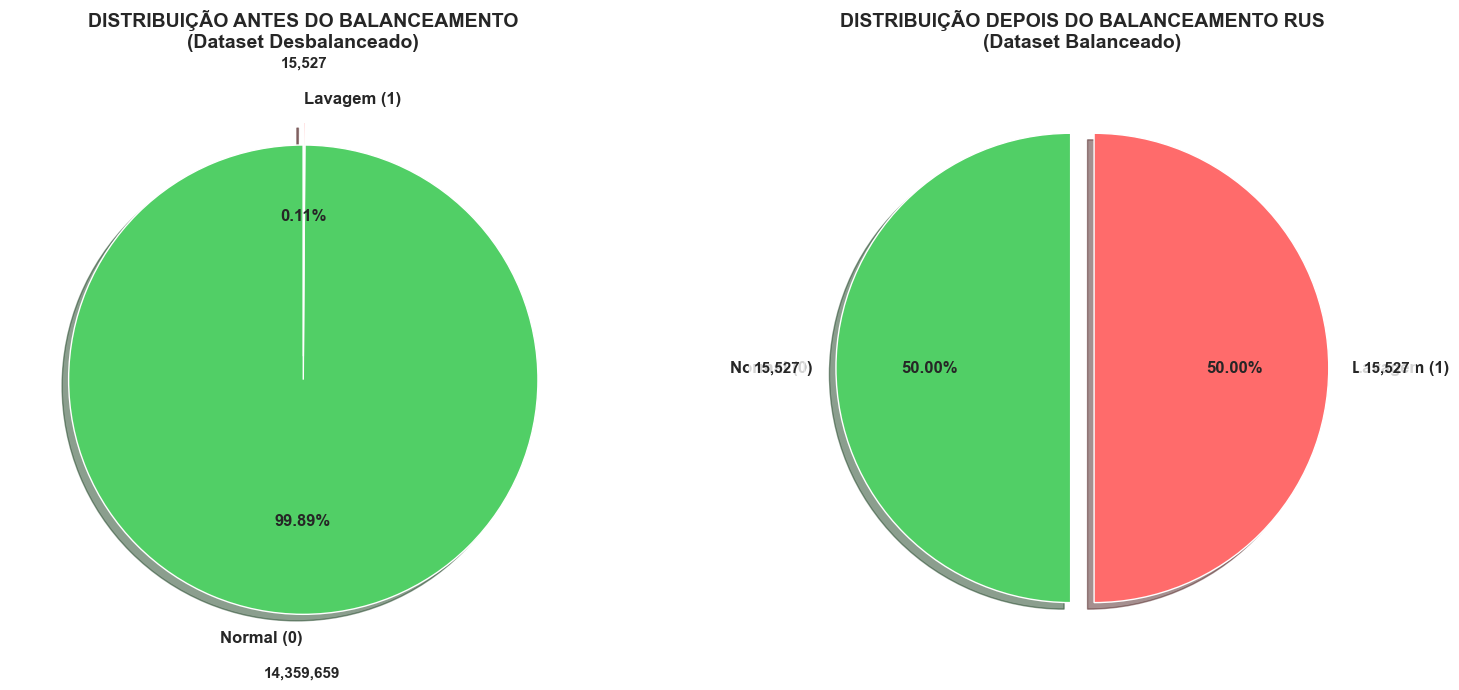


✅ TODAS AS VISUALIZAÇÕES FORAM CRIADAS COM SUCESSO!


In [14]:
# Criar gráficos de pizza comparativos
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Cores e labels
colors_pie = ['#51cf66', '#ff6b6b']
labels = ['Normal (0)', 'Lavagem (1)']
explode = (0.05, 0.05)  # Separar um pouco as fatias

# ========================================
# PIZZA 1: ANTES DO BALANCEAMENTO
# ========================================
wedges1, texts1, autotexts1 = axes[0].pie(
    before_values, 
    labels=labels, 
    colors=colors_pie,
    autopct='%1.2f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

axes[0].set_title('DISTRIBUIÇÃO ANTES DO BALANCEAMENTO\n(Dataset Desbalanceado)', 
                 fontsize=14, fontweight='bold', pad=20)

# Adicionar contagens
for i, (w, val) in enumerate(zip(wedges1, before_values)):
    angle = (w.theta2 + w.theta1) / 2
    x = 1.3 * np.cos(np.deg2rad(angle))
    y = 1.3 * np.sin(np.deg2rad(angle))
    axes[0].text(x, y, f'{val:,}', ha='center', va='center', 
                fontsize=11, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ========================================
# PIZZA 2: DEPOIS DO BALANCEAMENTO
# ========================================
wedges2, texts2, autotexts2 = axes[1].pie(
    after_values, 
    labels=labels, 
    colors=colors_pie,
    autopct='%1.2f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

axes[1].set_title('DISTRIBUIÇÃO DEPOIS DO BALANCEAMENTO RUS\n(Dataset Balanceado)', 
                 fontsize=14, fontweight='bold', pad=20)

# Adicionar contagens
for i, (w, val) in enumerate(zip(wedges2, after_values)):
    angle = (w.theta2 + w.theta1) / 2
    x = 1.3 * np.cos(np.deg2rad(angle))
    y = 1.3 * np.sin(np.deg2rad(angle))
    axes[1].text(x, y, f'{val:,}', ha='center', va='center', 
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()

# Salvar
output_path_pie = get_figure_path('comparacao_balanceamento_RUS_pizza.png')
plt.savefig(output_path_pie, dpi=300, bbox_inches='tight')
print(f"\n✅ Gráfico de pizza salvo em: {output_path_pie}")

plt.show()

print("\n" + "="*80)
print("✅ TODAS AS VISUALIZAÇÕES FORAM CRIADAS COM SUCESSO!")
print("="*80)